In [ ]:
dr = pd.read_excel('smiles_without_phosphorus_in_ring.xlsx')
del dr['ID']
dr.head()

In [ ]:
df = pd.read_csv("Morgan.csv")
del df['ID']
df.head()

In [43]:
morgan_file_path = 'Morgan.csv'
morgan_df = pd.read_csv(morgan_file_path)

df_without_phosphorus_in_ring = pd.read_excel('smiles_without_phosphorus_in_ring.xlsx')
if 'smiles' not in morgan_df.columns:
    raise ValueError("The column 'SMILES' was not found in the Morgan CSV file")

filtered_morgan_df = morgan_df[morgan_df['smiles'].isin(df_without_phosphorus_in_ring['smiles'])]
output_filtered_morgan = 'filtered_Morgan.csv'
filtered_morgan_df.to_csv(output_filtered_morgan, index=False)

num_filtered = len(morgan_df) - len(filtered_morgan_df)
print(f"Total rows in Morgan file: {len(morgan_df)}")
print(f"Rows filtered out (SMILES without phosphorus in a ring): {num_filtered}")
print(f"Filtered Morgan file saved to {output_filtered_morgan}")


Total rows in Morgan file: 1544
Rows filtered out (SMILES without phosphorus in a ring): 194
Filtered Morgan file saved to filtered_Morgan.csv


In [44]:
filtered_morgan_df.head()

,ID,smiles,morgan_fingerprint
0,1,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,2,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,3,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,4,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,5,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [45]:
del filtered_morgan_df['ID']
filtered_morgan_df.head()


,smiles,morgan_fingerprint
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...


In [47]:
def split_bits(row):
    if pd.isna(row['morgan_fingerprint']):
        return pd.Series([np.nan] * 1024)
    else:
        return pd.Series(list(row['morgan_fingerprint']))

bit_columns = filtered_morgan_df.apply(split_bits, axis=1)

bit_columns.columns = [f'F_{i+1}' for i in range(bit_columns.shape[1])]
final_df = pd.concat([df.reset_index(drop=True), bit_columns], axis=1)
final_df.head()

,smiles,morgan_fingerprint,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,0110100000000000000000000000000101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000000101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,0010100000000001000000000000001101000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,0110100000000001000000000000001101000000000001...,0,1,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,0010100000000000000000000000000100000000000001...,0,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [48]:
final_df = final_df.dropna()

y1 = dr[dr['smiles'].isin(final_df['smiles'])]

In [49]:
input = final_df.copy()
del input['morgan_fingerprint']
del input['smiles']
input.head()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_1015,F_1016,F_1017,F_1018,F_1019,F_1020,F_1021,F_1022,F_1023,F_1024
0,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [50]:
del y1['smiles']

In [53]:
for column in input.columns:
    if input[column].dtype == 'object':
        input[column] = pd.to_numeric(input[column], errors='coerce')

# Check the new data types
print(input.dtypes)

F_1       int64
F_2       int64
F_3       int64
F_4       int64
F_5       int64
          ...  
F_1020    int64
F_1021    int64
F_1022    int64
F_1023    int64
F_1024    int64
Length: 1024, dtype: object


In [54]:
y1.head()

,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,nbo_P_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
0,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,0.801914,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,0.816302,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
2,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,0.796412,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
3,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,0.798225,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
4,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,0.787516,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289


In [55]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [56]:
n_components = 5

abb = y1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(abb)

#pca = PCA(n_components=n_components)
#X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-transformed data
#pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

# Save the PCA-transformed data to a new CSV file
#pca_df.to_csv('pca.csv', index=False)

print("PCA transformation complete. Transformed data saved to 'pca.csv'.")


PCA transformation complete. Transformed data saved to 'pca.csv'.


In [57]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


SVM

In [34]:
import logging
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import optuna

In [73]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

X = input 
Y = abb.copy()

X = np.array(X) if isinstance(X, pd.DataFrame) else X

feature_names = Y.columns.tolist() if isinstance(Y, pd.DataFrame) else [f'feature_{i}' for i in range(Y.shape[1])]
Y = Y.to_numpy()  
results_list = []
model_dir = 'models_svm_val_cv'
os.makedirs(model_dir, exist_ok=True)

def objective(trial, X_train, y_train):

    params = {
        'C': trial.suggest_float('C', 1e-10, 1e3, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.0, 1.0),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid']),
    }
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 1, 5)
    else:
        params['degree'] = 1 

    if params['kernel'] in ['rbf', 'poly', 'sigmoid']:
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    else:
        params['gamma'] = 'scale'

    kf = KFold(n_splits=5)
    cv_mae_list = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        model = SVR(**params)
        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)
        cv_mae = mean_absolute_error(y_val_fold, y_val_pred)
        cv_mae_list.append(cv_mae)
    return np.mean(cv_mae_list)


for feature_index in range(Y.shape[1]):
    feature = feature_names[feature_index]  
    model_path = os.path.join(model_dir, f'model_{feature}.pkl')

    # Skip if model already exists
    if os.path.exists(model_path):
        logging.info(f"Model for feature '{feature}' already exists, skipping...")
        continue

    y = Y[:, feature_index] 
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    X_train = X_train.astype(np.float64)
    y_train = y_train.astype(np.float64)

    logging.info("Shapes for feature '%s': X_train: %s, y_train: %s", feature, X_train.shape, y_train.shape)

    study = optuna.create_study(direction='minimize')  # Minimize MAE
    try:
        study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=10)
    except Exception as e:
        logging.error(f"Error during optimization for feature '{feature}': {e}")
        continue
    
    best_params = study.best_params
    best_model = SVR(**best_params)
    best_model.fit(X_train, y_train)


    val_pred = best_model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)  
    val_r2 = r2_score(y_val, val_pred)  # Validation R²

    y_pred = best_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_pred) 
    test_r2 = r2_score(y_test, y_pred)  # Test R²

    # Store the results
    results_list.append({
        'Feature': feature,
        'Validation MAE': val_mae,
        'Validation R²': val_r2,
        'Test MAE': test_mae,
        'Test R²': test_r2,
        'Best Parameters': best_params
    })
    
    # Save the model
    joblib.dump(best_model, model_path)
    logging.info(f"Model for feature '{feature}' saved successfully.")

# Save all results to a CSV file
results_df = pd.DataFrame(results_list)
results_df.to_csv('model_performance_svm.csv', index=False)
logging.info("Best model performance metrics saved to 'model_performance_svm.csv'.")
logging.info("Best models saved in the 'models_svm_val_cv' directory.")


2024-10-10 21:08:19,975 - INFO - Shapes for feature 'vmin_vmin_boltz': X_train: (807, 1024), y_train: (807,)
[I 2024-10-10 21:08:19,976] A new study created in memory with name: no-name-38676216-c852-4f3f-9256-83e90051136a
[I 2024-10-10 21:08:20,198] Trial 0 finished with value: 0.01249734261836155 and parameters: {'C': 2.4338884094423285e-06, 'epsilon': 0.01956885982041301, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.01249734261836155.
[I 2024-10-10 21:08:20,255] Trial 1 finished with value: 0.017062182463446075 and parameters: {'C': 0.05401514956271925, 'epsilon': 0.9980276093338103, 'kernel': 'linear'}. Best is trial 0 with value: 0.01249734261836155.
[I 2024-10-10 21:08:20,325] Trial 2 finished with value: 0.017062182463446058 and parameters: {'C': 605.8869873697222, 'epsilon': 0.18959029393756233, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.01249734261836155.
[I 2024-10-10 21:08:20,363] Trial 3 finished with value: 0.0170621824634460

No need to run the following code if the previous one runs properly from start to end


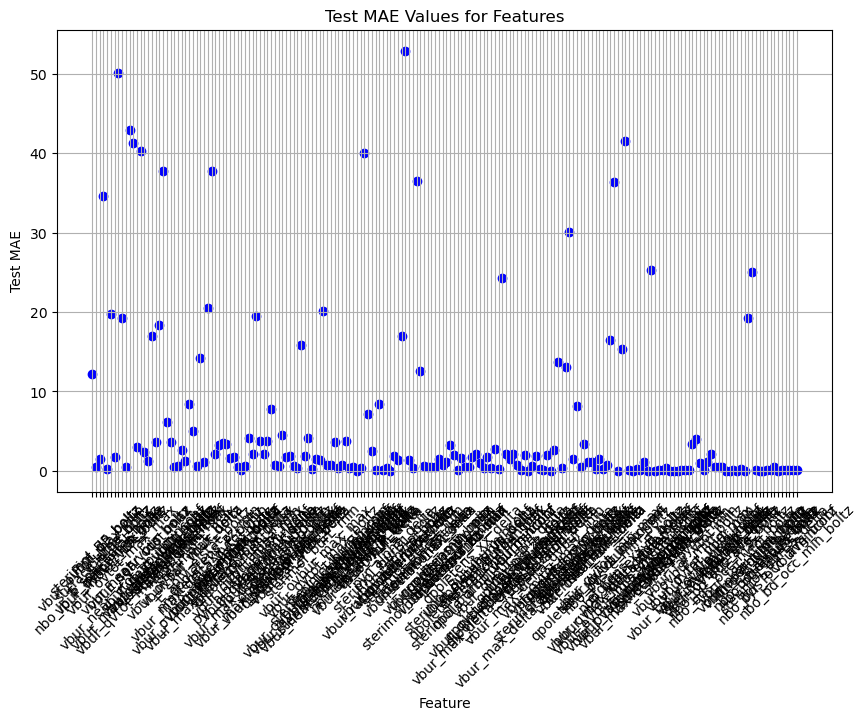

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('model_performance_svm.csv') #file path for csv or excel 
plt.figure(figsize=(10, 6))
plt.scatter(data['Feature'], data['Test MAE'], color='blue')
plt.title('Test MAE Values for Features')
plt.xlabel('Feature')
plt.ylabel('Test MAE')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [11]:
data.head()

,Feature,Validation MAE,Validation R²,Test MAE,R2,Best Parameters,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,vbur_ovtot_max_min,13.256759,0.765141,12.133015,0.845412,"{'C': 292.26543009002916, 'epsilon': 0.1097327...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Average,0.254254
1,sterimol_B5_boltz,0.458721,0.778477,0.435119,0.833244,"{'C': 32.79144769735057, 'epsilon': 0.02656671...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Max,0.845412
2,nbo_lp_P_percent_s_boltz,1.449743,0.826935,1.508370,0.833140,"{'C': 638.3272258854893, 'epsilon': 0.46609216...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,surface_area_boltz,34.781237,0.784336,34.627091,0.808407,"{'C': 12.96482438357037, 'epsilon': 0.40693067...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pint_dP_boltz,0.207892,0.781979,0.221185,0.806085,"{'C': 0.01944999515600801, 'epsilon': 0.068910...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


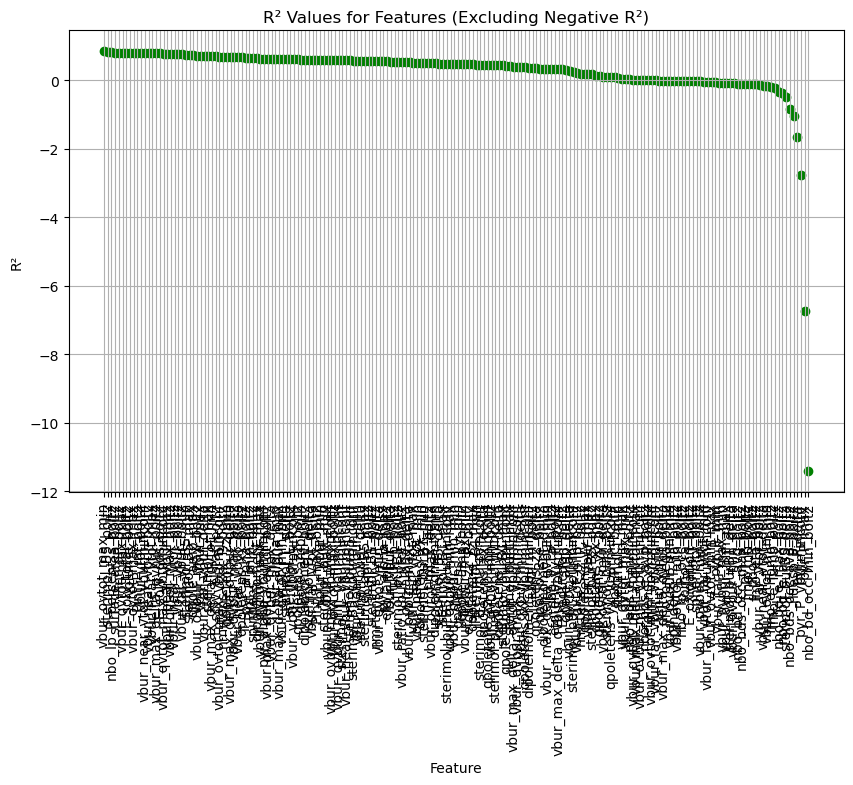

In [15]:
# Filter out rows with negative R²
filtered_data_r2 = data[data['R2'] >= -1000]
# Scatter plot for R²
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data_r2['Feature'], filtered_data_r2['R2'], color='green')
plt.title('R² Values for Features (Excluding Negative R²)')
plt.xlabel('Feature')
plt.ylabel('R²')
plt.xticks(rotation=90)
plt.grid()
plt.show()


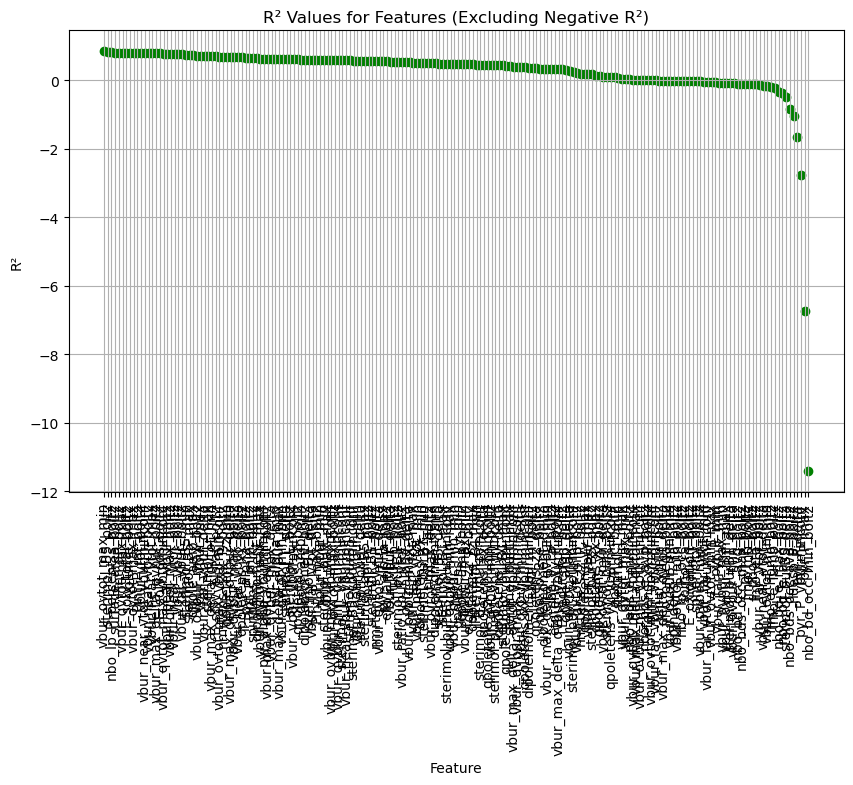

In [16]:
# Filter out rows with high negative R²
filtered_data_r2 = data[data['R2'] >= -100]
# Scatter plot for R²
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data_r2['Feature'], filtered_data_r2['R2'], color='green')
plt.title('R² Values for Features (Excluding Negative R²)')
plt.xlabel('Feature')
plt.ylabel('R²')
plt.xticks(rotation=90)
plt.grid()
plt.show()


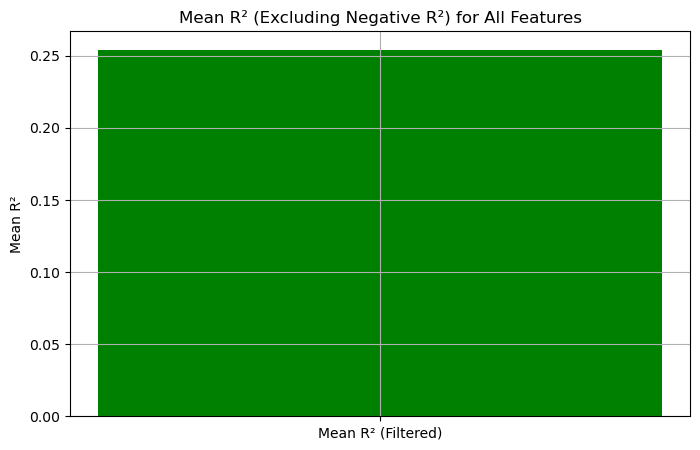

0.2542543175526316


In [17]:
mean_r2_filtered = filtered_data_r2['R2'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Mean R² (Filtered)'], [mean_r2_filtered], color='green')
plt.title('Mean R² (Excluding Negative R²) for All Features')
plt.ylabel('Mean R²')
plt.grid()
plt.show()
print(mean_r2_filtered)